# 1.EDA

In [1]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set(style="whitegrid")

# 📂 Step 2: Load the Cleaned Dataset
df = pd.read_csv("asthma_cleaned_dataset.csv")

# ✅ Step 3: Check Shape and Preview
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (2392, 28)


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,PollutionExposure,...,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis,FEV1_FVC_Ratio
0,63,0,1,0,15.848744,0,0.894448,5.488696,8.701003,7.388481,...,1.369051,4.941206,0,0,1,0,0,1,0,0.277068
1,26,1,2,2,22.757042,0,5.897329,6.341014,5.153966,1.969838,...,2.197767,1.702393,1,0,0,1,1,1,0,1.290987
2,57,0,2,1,18.395396,0,6.739367,9.196237,6.840647,1.460593,...,1.698011,5.022553,1,1,1,0,1,1,0,0.338077
3,40,1,2,1,38.515278,0,1.404503,5.826532,4.253036,0.581905,...,3.032037,2.300159,1,0,1,1,1,0,0,1.318186
4,61,0,0,3,19.283802,0,4.604493,3.127048,9.625799,0.980875,...,3.470589,3.067944,1,1,1,0,0,1,0,1.131243


In [3]:
# Recreate SymptomScore if it's not in the file
if "SymptomScore" not in df.columns:
    symptom_cols = [
        "Wheezing", "ShortnessOfBreath", "ChestTightness",
        "Coughing", "NighttimeSymptoms", "ExerciseInduced"
    ]
    df["SymptomScore"] = df[symptom_cols].sum(axis=1)


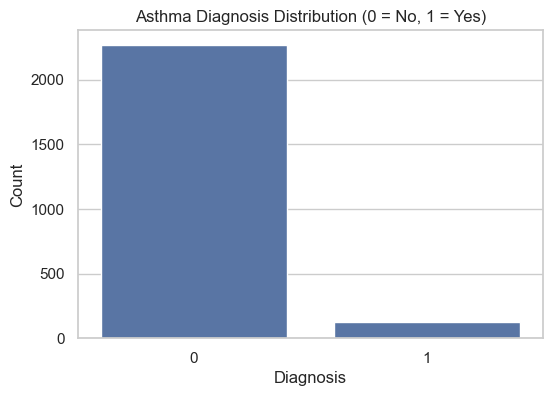

Diagnosis
0    2268
1     124
Name: count, dtype: int64


In [4]:
# Distribution of Asthma Diagnosis
plt.figure(figsize=(6, 4))
sns.countplot(x='Diagnosis', data=df)
plt.title("Asthma Diagnosis Distribution (0 = No, 1 = Yes)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

print(df['Diagnosis'].value_counts())


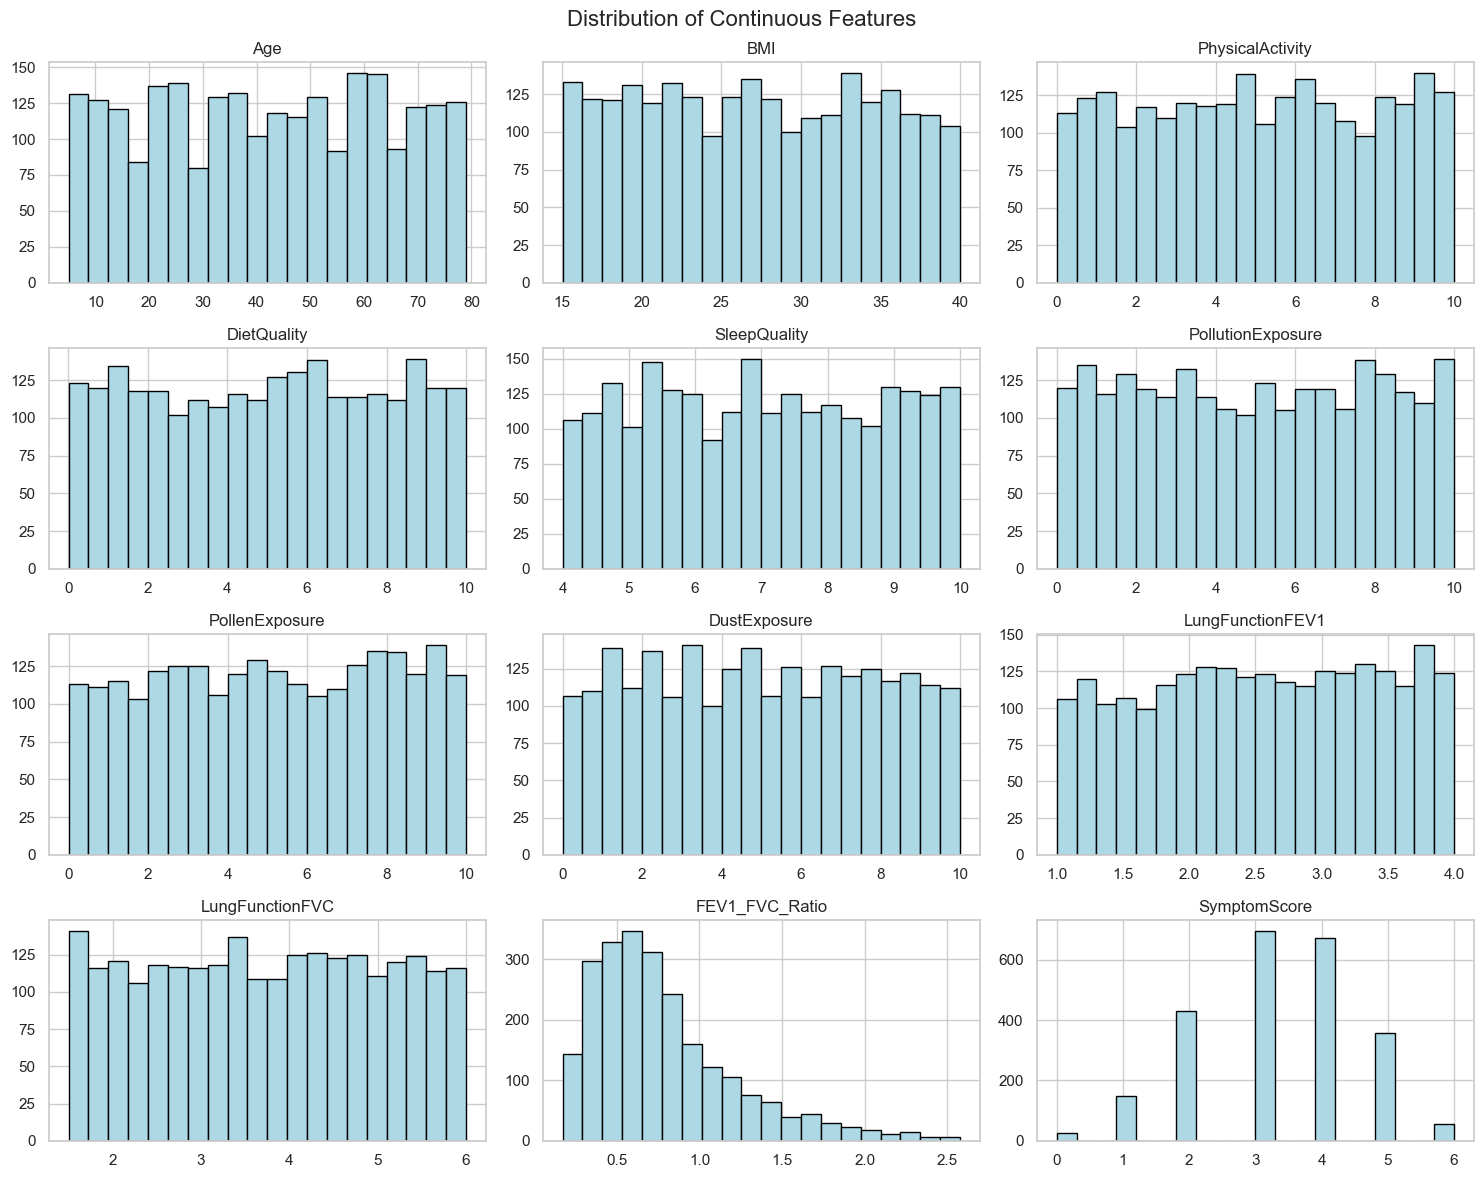

In [5]:
# Ensure FEV1_FVC_Ratio exists
if "FEV1_FVC_Ratio" not in df.columns:
    df["FEV1_FVC_Ratio"] = df["LungFunctionFEV1"] / df["LungFunctionFVC"]

# Continuous columns to plot
numeric_cols = [
    "Age", "BMI", "PhysicalActivity", "DietQuality", "SleepQuality",
    "PollutionExposure", "PollenExposure", "DustExposure",
    "LungFunctionFEV1", "LungFunctionFVC", "FEV1_FVC_Ratio", "SymptomScore"
]

# Plot histograms
df[numeric_cols].hist(figsize=(15, 12), bins=20, color='lightblue', edgecolor='black')
plt.suptitle("Distribution of Continuous Features", fontsize=16)
plt.tight_layout()
plt.show()


In [6]:
# Select important continuous features only (no one-hot, no IDs)
selected_features = [
    "Diagnosis", "Age", "BMI", "PhysicalActivity", "DietQuality", "SleepQuality",
    "PollutionExposure", "PollenExposure", "DustExposure",
    "LungFunctionFEV1", "LungFunctionFVC", "FEV1_FVC_Ratio", "SymptomScore"
]

# Create a smaller correlation matrix
corr_subset = df[selected_features].corr()


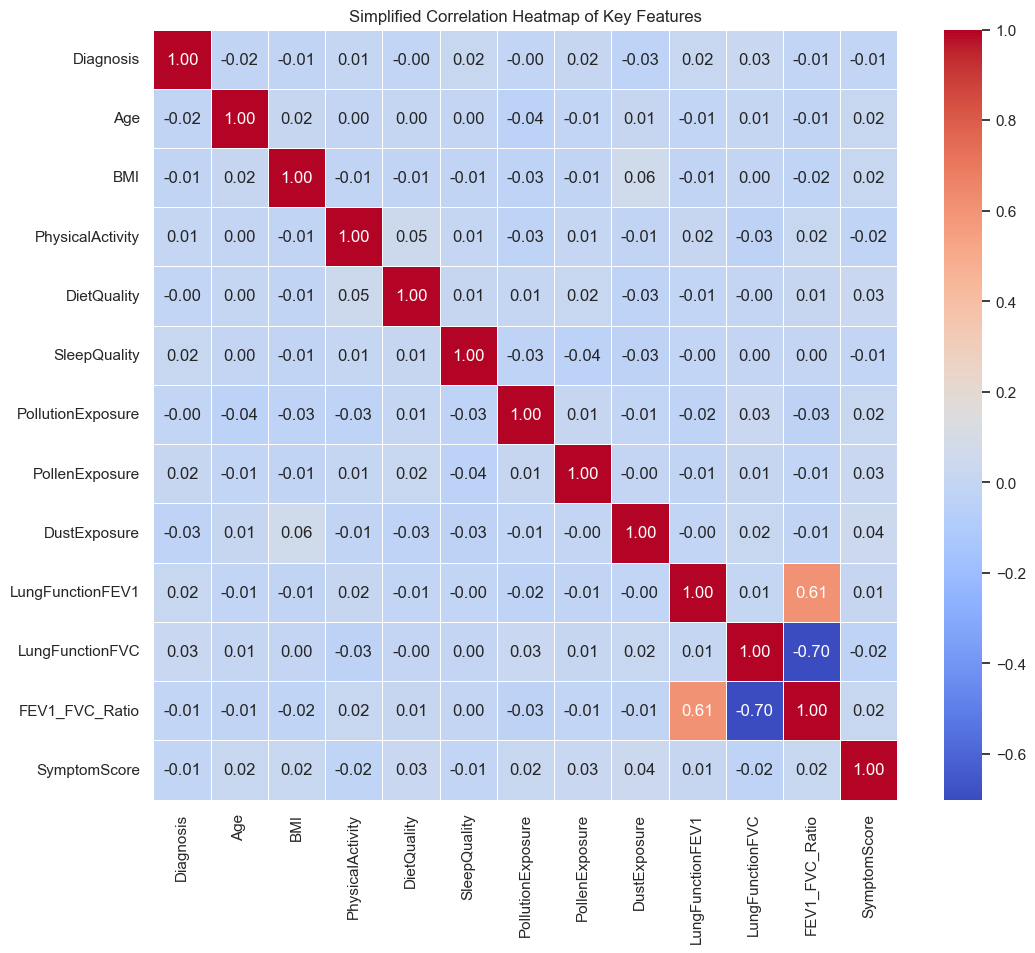

In [7]:
# Plot heatmap with selected features
plt.figure(figsize=(12, 10))
sns.heatmap(corr_subset, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Simplified Correlation Heatmap of Key Features")
plt.show()



C:\Users\RIMPY\AppData\Local\Temp\ipykernel_48324\2350609658.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=col, data=df, palette='Set2')
C:\Users\RIMPY\AppData\Local\Temp\ipykernel_48324\2350609658.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=col, data=df, palette='Set2')
C:\Users\RIMPY\AppData\Local\Temp\ipykernel_48324\2350609658.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=col, data=df, palette='Set2')
C:\Users\RIMPY\AppData\Local\Temp\ipykernel_48324\2350609658.py:7: 

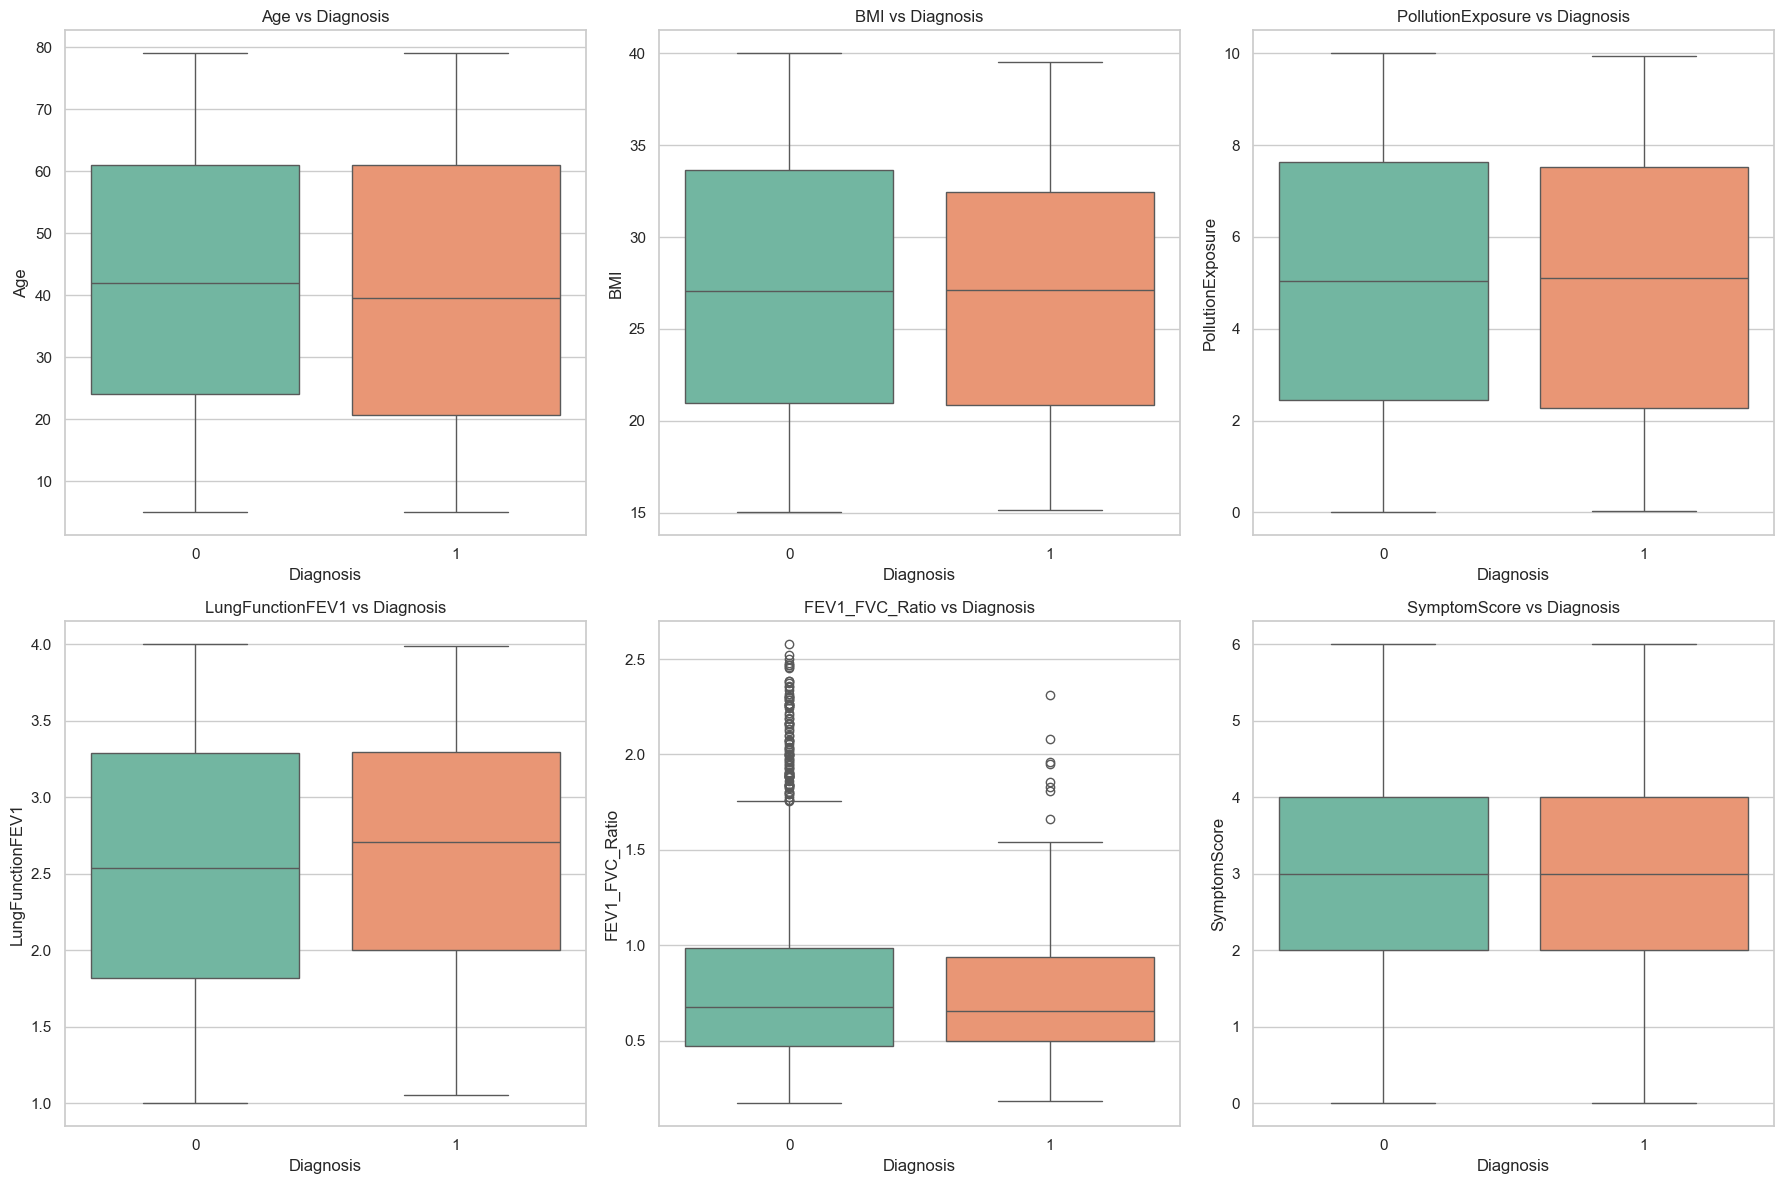

In [8]:
# Key continuous features to compare
top_features = ["Age", "BMI", "PollutionExposure", "LungFunctionFEV1", "FEV1_FVC_Ratio", "SymptomScore"]

plt.figure(figsize=(18, 12))
for i, col in enumerate(top_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='Diagnosis', y=col, data=df, palette='Set2')
    plt.title(f"{col} vs Diagnosis")
    plt.tight_layout()
plt.show()
